# Advanced Predictive Maintenance: Turbofan Engine Degradation (NASA C-MAPSS)

This project analyzes the C-MAPSS dataset provided by NASA's Ames Center of Excellence for Forecasting (PCoE). The simulation records multiple sensor channels to characterize the evolution of turbofan engine failures.

Instead of predicting the exact Remaining Useful Life (RUL) using classical regression, we modeled the problem as a **Multiclass Classification (Healthy, Alert, Critical)**.

To process both the dynamic temporal degradation (sliding sensor windows) and the static context (engine baseline signature and sub-dataset/operating regime via Embeddings), we developed a benchmark of five deep learning architectures. Model selection is done on the validation set and the benchmark reports, on a held-out test set, the F1-Score (Macro), Accuracy, and Execution Time (Efficiency).

---
## 1. Importing Libraries and Configuring the Environment

In [1]:
import pandas as pd
import numpy as np
import os
import copy
import math
import random
import time
import warnings
import matplotlib.pyplot as plt 
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Scikit-Learn
from sklearn.preprocessing import StandardScaler, LabelEncoder, FunctionTransformer, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score, accuracy_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Device Configuration (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(f"Using device: {device}")

# Reproducibility
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

Using device: cuda


---
## 2. Data Ingestion (C-MAPSS)
We load the 4 training sub-datasets (`train_FD001` ... `train_FD004`, run-to-failure trajectories) from the project's `data/` folder. A unique global identifier (`global_unit`) is guaranteed for each engine, essential to avoid mixing different time series.

In [2]:
# Relative path to the dataset (works when the notebook is run from notebooks/ or from the repo root)
path = os.path.join(os.pardir, "data") if os.path.isdir(os.path.join(os.pardir, "data")) else "data"

def load_and_combine_data(data_dir):
    # Column names according to official NASA C-MAPSS documentation
    index_names = ['unit_number', 'time_in_cycles']
    setting_names = ['op_setting_1', 'op_setting_2', 'op_setting_3']
    sensor_names = [f'sensor_{i}' for i in range(1,22)]
    col_names = index_names + setting_names + sensor_names
    
    datasets = ['FD001', 'FD002', 'FD003', 'FD004']
    train_list = []
    
    for ds in datasets:
        file_path = os.path.join(data_dir, f'train_{ds}.txt')
        if os.path.exists(file_path):
            # The separator in these files is a space.
            df = pd.read_csv(file_path, sep='\\s+', header=None, names=col_names)
            df['dataset_id'] = ds
            # Make the unit_number globally unique
            df['global_unit'] = df['dataset_id'] + '_' + df['unit_number'].astype(str)
            train_list.append(df)
        else:
            print(f"⚠️ Warning: File not found {file_path}")
            
    if not train_list:
        raise ValueError("No data was found in the specified path. Please check the files.")
        
    return pd.concat(train_list, ignore_index=True)

data = load_and_combine_data(path)
print(f"Total dimensions of the dataset: {data.shape}")
data.head()

Total dimensions of the dataset: (160359, 28)


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id,global_unit
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001,FD001_1
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001,FD001_1
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001,FD001_1
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001,FD001_1
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001,FD001_1


---
## 3. Problem Transformation and Cleanup
In the aeronautical industry, phased early warnings (risk zones) are preferable to a strict numerical regression that can be misinterpreted. We define the target variable ranges:
* **Healthy:** More than 60 cycles remaining until failure (RUL > 60).

* **Alert:** Between 31 and 60 cycles remaining (30 < RUL ≤ 60, maintenance is scheduled).

* **Critical:** 30 cycles or fewer until failure (RUL ≤ 30, AOG imminent).

In [3]:
def build_multiclass_target(df):
    df = df.copy()
    # Calculate actual Remaining Useful Life (RUL)
    max_cycles = df.groupby('global_unit')['time_in_cycles'].transform('max')
    df['RUL'] = max_cycles - df['time_in_cycles']
    
    # Create the target variable Multiclass
    df['failure_type'] = 'Healthy'
    df.loc[df['RUL'] <= 60, 'failure_type'] = 'Alert'
    df.loc[df['RUL'] <= 30, 'failure_type'] = 'Critical'
    
    return df

data = build_multiclass_target(data)
print("Distribution of Operating Classes:")
display(data["failure_type"].value_counts().to_frame())

# Basic Cleaning
data = data.drop_duplicates()

# RUL is removed to prevent direct data leakage (it is only used to build the target).
data = data.drop(columns=['RUL'])

Distribution of Operating Classes:


,count
failure_type,
Healthy,117110
Critical,21979
Alert,21270


---
## 4. Dynamic Exploratory Analysis (EDA)
Visualization of the behavior of representative sensors as the FD001_1 motor passes through operational risk zones.

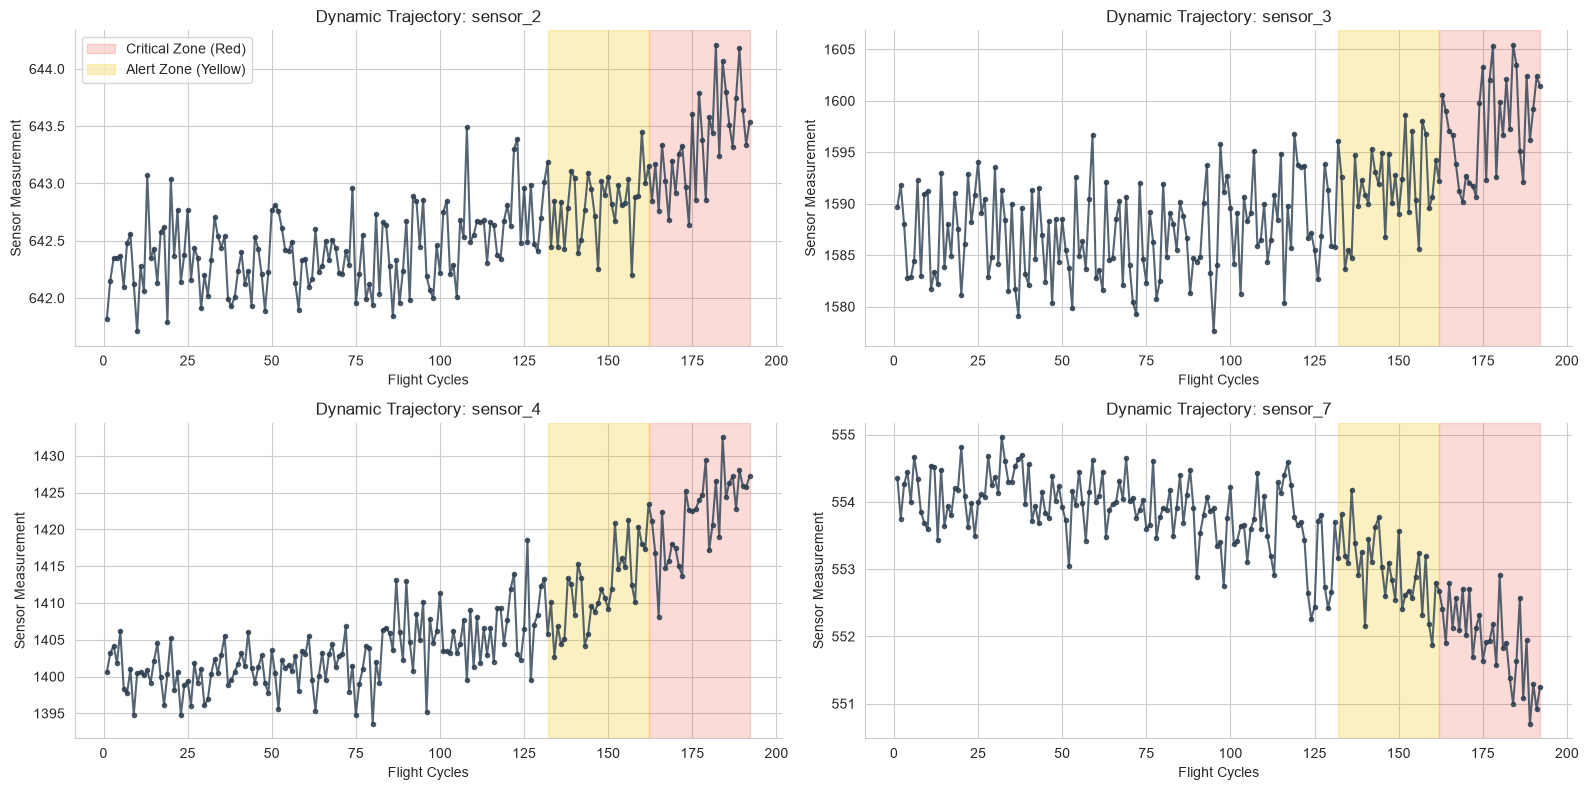

In [4]:
df_plot = data.copy()
cols_to_plot = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15']
cols_to_plot = [col for col in cols_to_plot if col in df_plot.columns]

# Temporal evolution of degradation for the Example Engine
unit_example = df_plot[df_plot['global_unit'] == 'FD001_1']

plt.figure(figsize=(16, 8))
sns.set_style('whitegrid')
for i, sensor in enumerate(cols_to_plot[:4], 1):
    plt.subplot(2, 2, i)
    plt.plot(unit_example['time_in_cycles'], unit_example[sensor], color='#2c3e50', marker='.', alpha=0.8, linewidth=1.5)
    plt.title(f'Dynamic Trajectory: {sensor}', fontsize=12)
    plt.xlabel('Flight Cycles')
    plt.ylabel('Sensor Measurement')
    
    # Visual mapping of risk zones (The Target)
    max_cyc = unit_example['time_in_cycles'].max()
    plt.axvspan(max_cyc - 30, max_cyc, color='#e74c3c', alpha=0.2, label='Critical Zone (Red)')
    plt.axvspan(max_cyc - 60, max_cyc - 30, color='#f1c40f', alpha=0.25, label='Alert Zone (Yellow)')
    if i == 1: 
        plt.legend(loc="upper left")

sns.despine()
plt.tight_layout()
plt.show()

---
## 5. Feature Engineering, Partitioning, and Scaling
**Critical Rule:** To prevent data leakage in forecast time series, we divide the dataset, ensuring that the time series from the same engine (`global_unit`) fall entirely into a single set (Train, Val, or Test).

In [5]:
def split_by_unit(df, test_size=0.15, val_size=0.15):
    gss1 = GroupShuffleSplit(n_splits=1, test_size=(test_size + val_size), random_state=42)
    train_idx, temp_idx = next(gss1.split(df, groups=df['global_unit']))
    temp_df = df.iloc[temp_idx].copy()
    
    proportion_test = test_size / (test_size + val_size)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=proportion_test, random_state=42)
    val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['global_unit']))
    
    return df.iloc[train_idx].copy(), temp_df.iloc[val_idx].copy(), temp_df.iloc[test_idx].copy()

train_data, val_data, test_data = split_by_unit(data)
print(f"Engines -> Train: {train_data['global_unit'].nunique()} | "
      f"Val: {val_data['global_unit'].nunique()} | Test: {test_data['global_unit'].nunique()}")

# Remove invariant sensors (variance 0). Statistics are computed on TRAIN only to avoid leakage.
sensor_cols = [col for col in train_data.columns if 'sensor' in col]
std_dev = train_data[sensor_cols].std()
invariant_sensors = std_dev[std_dev < 1e-6].index.tolist()
print(f"Invariant sensors removed (no useful signal): {invariant_sensors}")
train_data, val_data, test_data = [d.drop(columns=invariant_sensors) for d in (train_data, val_data, test_data)]

def feature_engineering(df):
    df = df.copy()
    sensor_cols = [c for c in df.columns if 'sensor' in c]
    
    # DYNAMIC FE: High-frequency noise smoothing (causal rolling windows: only past cycles are used)
    grouped = df.groupby('global_unit')[sensor_cols]
    
    roll_mean = grouped.transform(lambda x: x.rolling(window=5, min_periods=1).mean())
    roll_mean.columns = [f'{c}_roll_mean' for c in sensor_cols]
    
    roll_std = grouped.transform(lambda x: x.rolling(window=5, min_periods=1).std().fillna(0))
    roll_std.columns = [f'{c}_roll_std' for c in sensor_cols]
    
    df = pd.concat([df, roll_mean, roll_std], axis=1)
        
    # STATIC FE: Engine Signature (Baseline wear in the first 5 flights)
    # It calculates the average value of the sensors in the first 5 cycles of each unit, generating a baseline DataFrame per unit.
    baseline_df = df[df['time_in_cycles'] <= 5].groupby('global_unit')[sensor_cols].mean()
    baseline_df.columns = [f'static_base_{c}' for c in baseline_df.columns]
    df = df.merge(baseline_df, on='global_unit', how='left')
    df = df.drop(columns=['unit_number'])
    
    return df

feat_engineer = FunctionTransformer(feature_engineering, validate=False)
train_eng = feat_engineer.fit_transform(train_data)
val_eng   = feat_engineer.transform(val_data)
test_eng  = feat_engineer.transform(test_data)

# Target Encoding (LabelEncoder sorts alphabetically: Alert=0, Critical=1, Healthy=2)
le_y = LabelEncoder()
le_y.fit(['Healthy', 'Alert', 'Critical'])
y_train_enc, y_val_enc, y_test_enc = [le_y.transform(d['failure_type']) for d in (train_eng, val_eng, test_eng)]
train_eng, val_eng, test_eng = [d.drop(columns=['failure_type']) for d in (train_eng, val_eng, test_eng)]

# Standard Scaling of Sensors (Z-Score Normalization)
bypass_cols = ['global_unit', 'dataset_id', 'time_in_cycles']
num_cols = [c for c in train_eng.columns if c not in bypass_cols]

preprocessor = ColumnTransformer([
    ("scaler", StandardScaler(), num_cols)
], remainder="passthrough", verbose_feature_names_out=False)

preprocessor.set_output(transform="pandas")
X_train_scaled = preprocessor.fit_transform(train_eng)
X_val_scaled   = preprocessor.transform(val_eng)
X_test_scaled  = preprocessor.transform(test_eng)

# Categorical Encoder for creating Embeddings in PyTorch (index 0 is reserved for padding)
le_cat = LabelEncoder()
X_train_scaled['dataset_id_enc'] = le_cat.fit_transform(X_train_scaled['dataset_id']) + 1
X_val_scaled['dataset_id_enc']   = le_cat.transform(X_val_scaled['dataset_id']) + 1
X_test_scaled['dataset_id_enc']  = le_cat.transform(X_test_scaled['dataset_id']) + 1
cat_cardinalities = {'dataset_id_enc': len(le_cat.classes_) + 1}  # +1 for the padding index 0

print("Feature Engineering, Clean Partitioning and Z-Score Scaling Completed.")

Engines -> Train: 496 | Val: 106 | Test: 107
Invariant sensors removed (no useful signal): []


Feature Engineering, Clean Partitioning and Z-Score Scaling Completed.


---
## 6. Sliding Windows Modeling
Converts the 2D tabular dataset into three-dimensional tensors `[Batch, Time_Steps, Features]` ready to be consumed by PyTorch architectures.

In [6]:
def create_sequences_by_engine(df, y, seq_length=30):
    dyn_cols = [c for c in df.columns if ('sensor' in c or 'op_setting' in c) and 'static' not in c]
    stat_num_cols = [c for c in df.columns if 'static' in c]
    stat_cat_cols = ['dataset_id_enc']
    
    X_dyn_list, X_stat_num_list, X_stat_cat_list, y_list = [], [], [], []
    df = df.assign(target=y)  # avoid mutating the caller's DataFrame
    
    for _, group in df.groupby('global_unit'):
        dyn_data = group[dyn_cols].values
        stat_num_data = group[stat_num_cols].iloc[0].values 
        stat_cat_data = group[stat_cat_cols].iloc[0].values
        target_data = group['target'].values
        
        # Creating windows (1-step shift)
        for i in range(len(group) - seq_length + 1):
            X_dyn_list.append(dyn_data[i : i + seq_length])
            X_stat_num_list.append(stat_num_data)
            X_stat_cat_list.append(stat_cat_data)
            y_list.append(target_data[i + seq_length - 1])
            
    return (np.array(X_dyn_list, dtype=np.float32), np.array(X_stat_num_list, dtype=np.float32),
            np.array(X_stat_cat_list, dtype=np.int64), np.array(y_list, dtype=np.int64))

SEQ_LENGTH = 30
X_train_dyn, X_train_stat_num, X_train_stat_cat, y_train_seq = create_sequences_by_engine(X_train_scaled, y_train_enc, SEQ_LENGTH)
X_val_dyn, X_val_stat_num, X_val_stat_cat, y_val_seq         = create_sequences_by_engine(X_val_scaled, y_val_enc, SEQ_LENGTH)
X_test_dyn, X_test_stat_num, X_test_stat_cat, y_test_seq       = create_sequences_by_engine(X_test_scaled, y_test_enc, SEQ_LENGTH)

# Weight balancing due to natural imbalance (Healthy Class is majority)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_seq), y=y_train_seq)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

def build_dataloaders(X_dyn, X_num, X_cat, y, batch_size=256, shuffle=True):
    dataset = TensorDataset(
        torch.tensor(X_dyn, dtype=torch.float32),
        torch.tensor(X_num, dtype=torch.float32),
        torch.tensor(X_cat[:, 0], dtype=torch.long),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = build_dataloaders(X_train_dyn, X_train_stat_num, X_train_stat_cat, y_train_seq, shuffle=True)
val_loader   = build_dataloaders(X_val_dyn, X_val_stat_num, X_val_stat_cat, y_val_seq, shuffle=False)
test_loader  = build_dataloaders(X_test_dyn, X_test_stat_num, X_test_stat_cat, y_test_seq, shuffle=False)

print(f"Ready-to-use 3D dynamic tensors [Windows, Time_Steps, Features]:")
print(f"  Train: {X_train_dyn.shape} | Val: {X_val_dyn.shape} | Test: {X_test_dyn.shape}")

Ready-to-use 3D dynamic tensors [Windows, Time_Steps, Features]:
  Train: (98582, 30, 66) | Val: (20575, 30, 66) | Test: (20641, 30, 66)


---
## 7. Advanced Deep Learning Architectures
Design and implementation of 5 high-performance architectures in PyTorch. All merge the representation of the dynamic temporal window with the static characteristics of the engine.

In [7]:
input_dyn_sz = X_train_dyn.shape[2]
input_stat_sz = X_train_stat_num.shape[1]

# ==========================================
# MODEL 1: FCN (Baseline Classic and Strong)
# ==========================================
class FCNBaseline(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        # cat_cardinalities['dataset_id_enc'] = number of sub-datasets + 1 (index 0 reserved for padding)
        self.emb = nn.Embedding(cat_cardinalities['dataset_id_enc'], 10, padding_idx=0)
        # Conv1d receives (Batch, Channels, Length)
        self.conv1 = nn.Conv1d(input_dyn_sz, 128, 8, padding='same')
        self.bn1 = nn.BatchNorm1d(128)
        self.conv2 = nn.Conv1d(128, 256, 5, padding='same')
        self.bn2 = nn.BatchNorm1d(256)
        self.conv3 = nn.Conv1d(256, 128, 3, padding='same')
        self.bn3 = nn.BatchNorm1d(128)
        
        self.mlp = nn.Sequential(
            nn.Linear(128 + input_stat_sz + 10, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

    def forward(self, x_dyn, x_num, x_cat):
        x = x_dyn.permute(0, 2, 1) # [B, F, S]
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        # Global Average Pooling
        h = x.mean(dim=2) 
        
        emb_out = self.emb(x_cat)
        combined = torch.cat([h, x_num, emb_out], dim=1)
        return self.mlp(combined)

# ==========================================
# MODEL 2: InceptionTime (SOTA CNN Time Series)
# ==========================================
class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        bottleneck_size = 32 if in_channels > 32 else in_channels
        self.bottleneck = nn.Conv1d(in_channels, bottleneck_size, 1, bias=False) if in_channels > 32 else nn.Identity()
        
        self.conv1 = nn.Conv1d(bottleneck_size, out_channels, kernel_size=10, padding='same', bias=False)
        self.conv2 = nn.Conv1d(bottleneck_size, out_channels, kernel_size=20, padding='same', bias=False)
        self.conv3 = nn.Conv1d(bottleneck_size, out_channels, kernel_size=40, padding='same', bias=False)
        
        self.maxpool = nn.MaxPool1d(3, stride=1, padding=1)
        self.conv_pool = nn.Conv1d(in_channels, out_channels, 1, bias=False)
        
        self.bn = nn.BatchNorm1d(out_channels * 4)

    def forward(self, x):
        x_bot = self.bottleneck(x)
        c1 = self.conv1(x_bot)
        c2 = self.conv2(x_bot)
        c3 = self.conv3(x_bot)
        p1 = self.conv_pool(self.maxpool(x))
        out = torch.cat([c1, c2, c3, p1], dim=1)
        return F.relu(self.bn(out))

class InceptionTime(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.inception1 = InceptionModule(input_dyn_sz, 32)
        self.inception2 = InceptionModule(128, 32)
        self.emb = nn.Embedding(cat_cardinalities['dataset_id_enc'], 10, padding_idx=0)
        
        self.mlp = nn.Sequential(
            nn.Linear(128 + input_stat_sz + 10, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )
        
    def forward(self, x_dyn, x_num, x_cat):
        x = x_dyn.permute(0, 2, 1) # [B, F, S]
        x = self.inception1(x)
        x = self.inception2(x)
        h = x.mean(dim=2) # GAP
        
        emb_out = self.emb(x_cat)
        combined = torch.cat([h, x_num, emb_out], dim=1)
        return self.mlp(combined)

# ==========================================
# MODEL 3: Time Series Transformer
# ==========================================
# UTILITY: Positional Encoding for Transformers
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TimeSeriesTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.input_linear = nn.Linear(input_dyn_sz, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=128, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        
        self.emb = nn.Embedding(cat_cardinalities['dataset_id_enc'], 10, padding_idx=0)
        self.mlp = nn.Sequential(
            nn.Linear(d_model + input_stat_sz + 10, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

    def forward(self, x_dyn, x_num, x_cat):
        x_t = self.input_linear(x_dyn)
        x_t = self.pos_encoder(x_t)
        out_tf = self.transformer_encoder(x_t)
        
        h = out_tf.mean(dim=1) # Global Average Pooling
        
        emb_out = self.emb(x_cat)
        combined = torch.cat([h, x_num, emb_out], dim=1)
        return self.mlp(combined)

# ==========================================
# MODEL 4: PatchTST (Patch Time Series Transformer - Classification)
# ==========================================
class PatchTST(nn.Module):
    def __init__(self, seq_len=SEQ_LENGTH, patch_len=10, stride=10, n_features=input_dyn_sz, d_model=64, nhead=4, dropout=0.3):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        self.num_patches = (seq_len - patch_len) // stride + 1
        
        self.patch_proj = nn.Linear(patch_len * n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model) 
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        self.emb = nn.Embedding(cat_cardinalities['dataset_id_enc'], 10, padding_idx=0)
        self.mlp = nn.Sequential(
            nn.Linear(d_model + input_stat_sz + 10, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

    def forward(self, x_dyn, x_num, x_cat):
        # Patch Creation
        patches = x_dyn.unfold(dimension=1, size=self.patch_len, step=self.stride)  # [B, N, F, P]
        B, num_patches, n_feat, p_len = patches.shape  # (do not shadow torch.nn.functional as F)
        patches = patches.reshape(B, num_patches, n_feat * p_len)
        
        x_t = self.patch_proj(patches)
        x_t = self.pos_encoder(x_t) 
        out = self.transformer(x_t)
        h = out.mean(dim=1)
        
        emb_out = self.emb(x_cat)
        combined = torch.cat([h, x_num, emb_out], dim=1)
        return self.mlp(combined)

# ==========================================
# MODEL 5: ConvTransformer (Hybrid CNN-Self Attention)
# ==========================================
class ConvTransformer(nn.Module):
    def __init__(self, n_features=input_dyn_sz, d_model=64, nhead=4, dropout=0.3):
        super().__init__()
        self.conv = nn.Conv1d(in_channels=n_features, out_channels=d_model, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm1d(d_model)
        self.pos_encoder = PositionalEncoding(d_model) 
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        self.emb = nn.Embedding(cat_cardinalities['dataset_id_enc'], 10, padding_idx=0)
        self.mlp = nn.Sequential(
            nn.Linear(d_model + input_stat_sz + 10, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3)
        )

    def forward(self, x_dyn, x_num, x_cat):
        x = x_dyn.permute(0, 2, 1) # [B, F, S]
        x = F.relu(self.bn(self.conv(x)))
        x = x.permute(0, 2, 1) # [B, S, F]
        x = self.pos_encoder(x) 
        
        out = self.transformer(x)
        h = out.mean(dim=1)
        
        emb_out = self.emb(x_cat)
        combined = torch.cat([h, x_num, emb_out], dim=1)
        return self.mlp(combined)

---
## 8. Training Loop (Early Stopping and Time Profiling)
A routine that will iterate over all models. We implemented **Early Stopping** (restoring the weights of the best validation epoch) to mitigate overfitting and recorded the **Training Time** as a critical feasibility metric.

The best model is selected by **validation Macro F1**; the test set is only used to report the final, unbiased metrics.

In [8]:
def train_evaluate_classification(model, model_name, train_loader, val_loader, epochs=25, lr=1e-3, patience=4):
    print(f"\n{'='*45}\nTraining: {model_name}\n{'='*45}")
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    best_val, no_improve = float("inf"), 0
    best_state = None
    start_time = time.time()
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for x_dyn, x_num, x_cat, yb in train_loader:
            x_dyn, x_num, x_cat, yb = x_dyn.to(device), x_num.to(device), x_cat.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(x_dyn, x_num, x_cat)
            loss = criterion(preds, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        
        train_mean = train_loss / len(train_loader)
            
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_dyn, x_num, x_cat, yb in val_loader:
                x_dyn, x_num, x_cat, yb = x_dyn.to(device), x_num.to(device), x_cat.to(device), yb.to(device)
                preds = model(x_dyn, x_num, x_cat)
                loss = criterion(preds, yb)
                val_loss += loss.item()
                
        val_mean = val_loss / len(val_loader)
        
        # Early Stopping Logic
        if val_mean < best_val:
            best_val, no_improve = val_mean, 0
            # deepcopy: state_dict() returns references that keep changing during training
            best_state = copy.deepcopy(model.state_dict())
            status = "Saved"
        else:
            no_improve += 1
            status = ""
            
        print(f"Epoch {epoch:2d} | Train Loss: {train_mean:.4f} | Val Loss: {val_mean:.4f} {status}")
            
        if no_improve >= patience:
            print(f"Early stopping activated at epoch {epoch}")
            break
            
    execution_time = time.time() - start_time
    model.load_state_dict(best_state)
    
    return model, execution_time

# Standardized inference function extracting predictions and probabilities.
def get_predictions(model, loader):
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    
    with torch.no_grad():
        for x_dyn, x_num, x_cat, yb in loader:
            x_dyn, x_num, x_cat = x_dyn.to(device), x_num.to(device), x_cat.to(device)
            out = model(x_dyn, x_num, x_cat)
            probs = F.softmax(out, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            y_true.extend(yb.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
    
    return np.array(y_true), np.array(y_pred), np.array(y_probs)

# Dictionary of model constructors (each model is built right after fixing the seed -> reproducible init)
model_builders = {
    "FCN (Baseline)": FCNBaseline,
    "InceptionTime": InceptionTime,
    "TimeSeriesTransformer": TimeSeriesTransformer,
    "PatchTST": PatchTST,
    "ConvTransformer": ConvTransformer
}

# Dictionaries to consolidate results
benchmark_results = []
predictions_dict = {}

# Run Loop for the entire Pipeline
for name, builder in model_builders.items():
    set_seed()
    model = builder().to(device)
    trained_model, exec_time = train_evaluate_classification(model, name, train_loader, val_loader)

    # Validation metrics -> used for model selection
    yv_true, yv_pred, _ = get_predictions(trained_model, val_loader)
    # Test metrics -> final unbiased evaluation
    y_true, y_pred, y_probs = get_predictions(trained_model, test_loader)

    benchmark_results.append({
        'Model': name,
        'Val Macro F1': f1_score(yv_true, yv_pred, average='macro'),
        'Macro F1': f1_score(y_true, y_pred, average='macro'),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Time (s)': exec_time
    })

    predictions_dict[name] = {'y_true': y_true, 'y_pred': y_pred, 'y_probs': y_probs}

df_results = pd.DataFrame(benchmark_results)


Training: FCN (Baseline)


Epoch  0 | Train Loss: 0.6273 | Val Loss: 0.6209 Saved


Epoch  1 | Train Loss: 0.5463 | Val Loss: 0.8584 


Epoch  2 | Train Loss: 0.4979 | Val Loss: 0.8107 


Epoch  3 | Train Loss: 0.4556 | Val Loss: 0.7407 


...

Epoch  4 | Train Loss: 0.4687 | Val Loss: 0.5059 Saved


Epoch  5 | Train Loss: 0.4436 | Val Loss: 0.5526 


Epoch  6 | Train Loss: 0.4087 | Val Loss: 0.6422 


Epoch  7 | Train Loss: 0.3833 | Val Loss: 0.6668 


Epoch  8 | Train Loss: 0.3603 | Val Loss: 0.5588 
Early stopping activated at epoch 8


---
## 9. Results and Comparative Graphs
We will now compare the results and computational requirements of the benchmark. The best model (highest **validation** Macro F1) is analyzed on the test set through its Confusion Matrix, its One-vs-Rest ROC Curves and its classification report.

*Macro F1 and Accuracy in the table/plots are test-set metrics.*

,Model,Val Macro F1,Macro F1,Accuracy,Time (s)
2,TimeSeriesTransformer,0.773924,0.793651,0.833535,220.634334
3,PatchTST,0.779031,0.791977,0.841384,504.279174
1,InceptionTime,0.723373,0.752524,0.802529,103.890573
4,ConvTransformer,0.750194,0.737664,0.791967,212.856255
0,FCN (Baseline),0.683337,0.681389,0.750157,133.594733


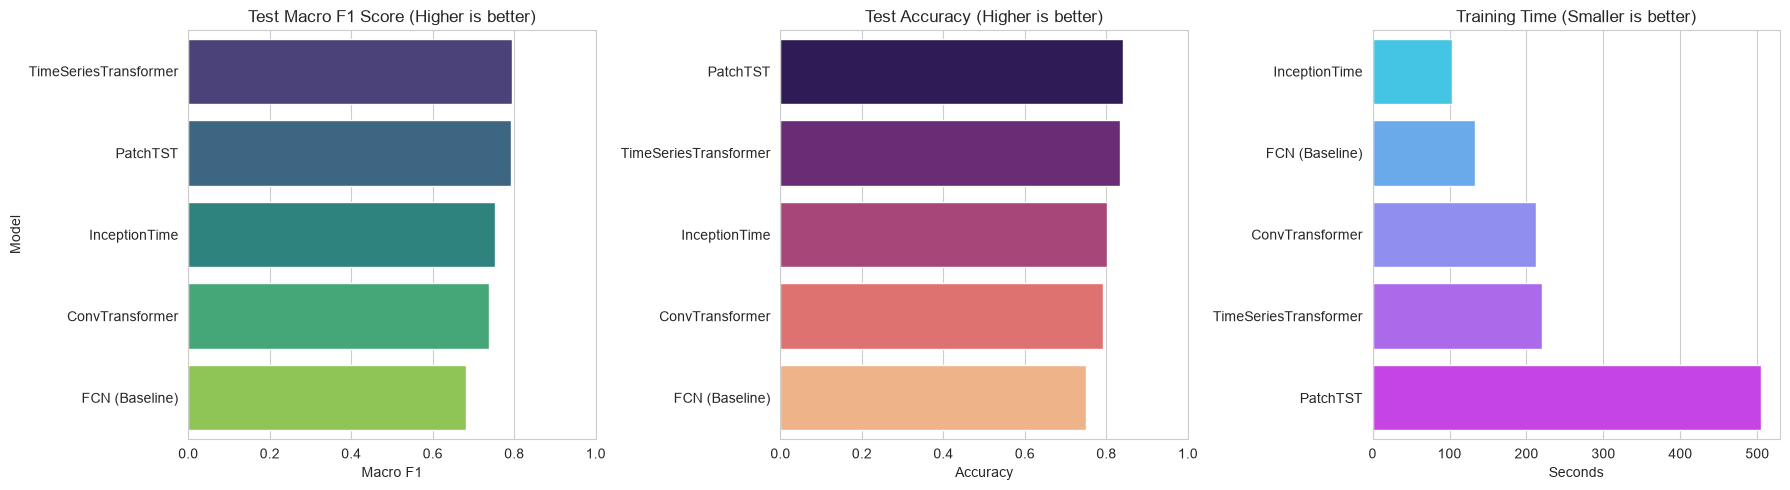


The overall winner of the benchmark (best validation Macro F1) is: PatchTST


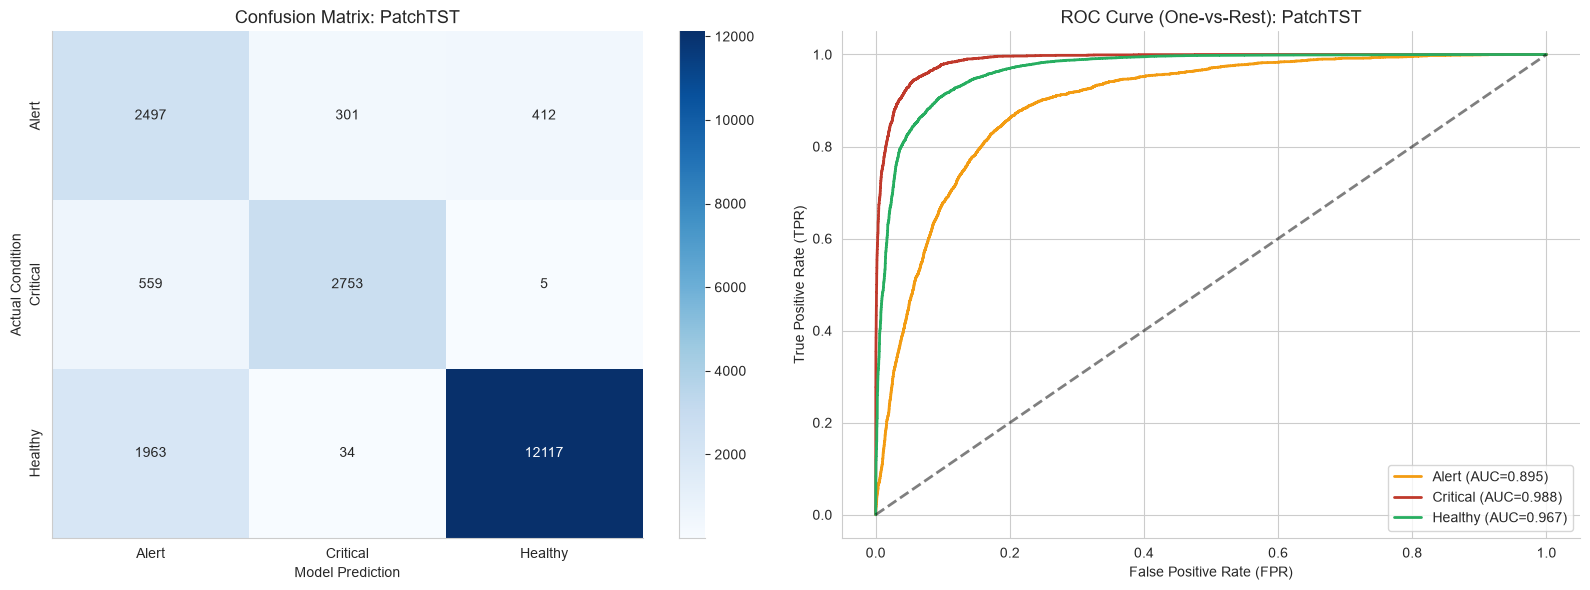


Detailed Report (PatchTST):
              precision    recall  f1-score   support

       Alert       0.50      0.78      0.61      3210
    Critical       0.89      0.83      0.86      3317
     Healthy       0.97      0.86      0.91     14114

    accuracy                           0.84     20641
   macro avg       0.79      0.82      0.79     20641
weighted avg       0.88      0.84      0.85     20641



In [9]:
display(df_results.sort_values(by='Macro F1', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_style('whitegrid')

# Plot Macro F1
sns.barplot(data=df_results.sort_values('Macro F1', ascending=False), x='Macro F1', y='Model', hue='Model', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Test Macro F1 Score (Higher is better)', fontsize=12)
axes[0].set_xlabel('Macro F1')
axes[0].set_xlim(0, 1.0)

# Plot Accuracy
sns.barplot(data=df_results.sort_values('Accuracy', ascending=False), x='Accuracy', y='Model', hue='Model', palette='magma', legend=False, ax=axes[1])
axes[1].set_title('Test Accuracy (Higher is better)', fontsize=12)
axes[1].set_xlabel('Accuracy')
axes[1].set_xlim(0, 1.0)
axes[1].set_ylabel('')

# Plot Time
sns.barplot(data=df_results.sort_values('Time (s)'), x='Time (s)', y='Model', hue='Model', palette='cool', legend=False, ax=axes[2])
axes[2].set_title('Training Time (Smaller is better)', fontsize=12)
axes[2].set_xlabel('Seconds')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# =========================================================================
# ISOLATED ANALYSIS OF THE BEST MODEL
# =========================================================================
# Selection on VALIDATION to avoid optimistic bias from choosing the model on the test set
best_model_name = df_results.loc[df_results['Val Macro F1'].idxmax(), 'Model']
print(f"\nThe overall winner of the benchmark (best validation Macro F1) is: {best_model_name}")
y_true = predictions_dict[best_model_name]['y_true']
best_preds = predictions_dict[best_model_name]['y_pred']
best_probs = predictions_dict[best_model_name]['y_probs']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_true, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_y.classes_, yticklabels=le_y.classes_, ax=axes[0])
axes[0].set_xlabel('Model Prediction')
axes[0].set_ylabel('Actual Condition')
axes[0].set_title(f'Confusion Matrix: {best_model_name}', fontsize=13)

# 2. Multiclass ROC Curve (One-vs-Rest)
y_test_bin = label_binarize(y_true, classes=[0, 1, 2])
class_colors = {'Healthy': '#27ae60', 'Alert': '#f39c12', 'Critical': '#c0392b'}
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_probs[:, i])
    roc_auc = auc(fpr, tpr)
    class_name = le_y.classes_[i]
    axes[1].plot(fpr, tpr, lw=2, color=class_colors[class_name], label=f'{class_name} (AUC={roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title(f"ROC Curve (One-vs-Rest): {best_model_name}", fontsize=13)
axes[1].legend(loc="lower right")

sns.despine()
plt.tight_layout()
plt.show()

print(f"\nDetailed Report ({best_model_name}):")
print(classification_report(y_true, best_preds, target_names=le_y.classes_))